In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

#make all images same dimensiona
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
#store path to where data set is located
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/Combined Dataset"

dataset = ImageFolder(
    root=DATASET_PATH,
    transform=transform
)

# 80/20 split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_set, test_set = random_split(dataset, [train_size, test_size])

#loads 64 train images at a time in shuffled order
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
#loads 64 test imgages at a time in given order, ored does not matter here
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

In [ ]:
#verify labels and amount of trainig data
print(dataset.classes)
print(len(train_set))
print(len(test_set))

['cardboard', 'compost', 'glass', 'metal', 'paper', 'plastic', 'trash']
5691
1423


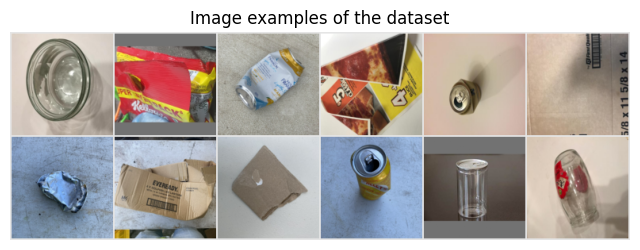

In [ ]:
# Visualize some examples to see if data is loaded correctly
import torch
import matplotlib.pyplot as plt
import torchvision
import numpy as np

NUM_IMAGES = 12
waste_images = torch.stack([train_set[np.random.randint(len(train_set))][0] for idx in range(NUM_IMAGES)], dim=0)
img_grid = torchvision.utils.make_grid(waste_images, nrow=6, normalize=True, pad_value=0.9)
img_grid = img_grid.permute(1, 2, 0)

plt.figure(figsize=(8,8))
plt.title("Image examples of the dataset")
plt.imshow(img_grid)
plt.axis('off')
plt.show()
plt.close()

based off code from: https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial16/Meta_Learning.ipynb


In [ ]:
N_WAY = 3          # 3 waste classes
K_SHOT = 5       # example: k-shot learning

In [22]:
#This function builds a DenseNet CNN whose final output size equals your embedding dimension for few-shot learning.
def get_convnet(output_size):
    convnet = torchvision.models.DenseNet(growth_rate=32,
                                          block_config=(6, 6, 6, 6),
                                          bn_size=2,
                                          num_init_features=64,
                                          num_classes=output_size  # Output dimensionality
                                         )
    return convnet
import torchvision
!pip install pytorch_lightning
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F

#def get_convnet(output_size, pretrained=True):
#    weights = models.MobileNet_V3_Small_Weights.DEFAULT if pretrained else None
#    model = models.mobilenet_v3_small(weights=weights)
#    in_features = model.classifier[-1].in_features
#    model.classifier[-1] = nn.Linear(in_features, output_size)
#    return model

In [7]:
#defines your Prototypical Network model using PyTorch Lightning It organizes training, validation, optimization, and logging automatically.


# PyTorch Lightning, not in colab so will likly have to install
try:
    import pytorch_lightning as pl
except ModuleNotFoundError: # Google Colab does not have PyTorch Lightning installed by default. Hence, we do it here if necessary
    !pip install --quiet pytorch-lightning>=1.4
    import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint


#class that creates protonet model
class ProtoNet(pl.LightningModule):
#For each episode: Get support + query images, Encode with DenseNet, Compute class prototypes, Compute distance from query to prototypes,Compute cross-entropy loss, Backpropagate
    def __init__(self, proto_dim, lr):
        """
        Inputs
            proto_dim - Dimensionality of prototype feature space
            lr - Learning rate of Adam optimizer
        """
        super().__init__()
        self.save_hyperparameters()
        self.model = get_convnet(output_size=self.hparams.proto_dim)

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=self.hparams.lr)
        scheduler = optim.lr_scheduler.MultiStepLR(
            optimizer, milestones=[140, 180], gamma=0.1) #at these two epochs learning rate multiplied by 0.1
        return [optimizer], [scheduler]

    @staticmethod
    def calculate_prototypes(features, targets):
        # Given a stack of features vectors and labels, return class prototypes
        # features - shape [N, proto_dim], targets - shape [N]
        classes, _ = torch.unique(targets).sort()  # Determine which classes we have
        prototypes = []
        for c in classes:
            p = features[torch.where(targets == c)[0]].mean(dim=0)  # Average class feature vectors
            prototypes.append(p)
        prototypes = torch.stack(prototypes, dim=0)
        # Return the 'classes' tensor to know which prototype belongs to which class
        return prototypes, classes

    def classify_feats(self, prototypes, classes, feats, targets):
        # Classify new examples with prototypes and return classification error
        dist = torch.pow(prototypes[None, :] - feats[:, None], 2).sum(dim=2)  # calculat Squared euclidean distance to proto type
        preds = F.log_softmax(-dist, dim=1) #converts to a probability
        labels = (classes[None, :] == targets[:, None]).long().argmax(dim=-1)
        acc = (preds.argmax(dim=1) == labels).float().mean()
        return preds, labels, acc

    def calculate_loss(self, batch, mode):
        # Determine training loss for a given support and query set
        imgs, targets = batch
        features = self.model(imgs)  # Encode all images of support and query set
        support_feats, query_feats, support_targets, query_targets = split_batch(features, targets)
        prototypes, classes = ProtoNet.calculate_prototypes(support_feats, support_targets)
        preds, labels, acc = self.classify_feats(prototypes, classes, query_feats, query_targets)
        loss = F.cross_entropy(preds, labels)

        self.log(f"{mode}_loss", loss)
        self.log(f"{mode}_acc", acc)
        return loss

    def training_step(self, batch, batch_idx):
        return self.calculate_loss(batch, mode="train")

    def validation_step(self, batch, batch_idx):
        _ = self.calculate_loss(batch, mode="val")

In [ ]:

# Import tensorboard
%load_ext tensorboard

# Path to the folder where the datasets are/should be downloaded (e.g. CIFAR10)
DATASET_PATH = "../data"
# Path to the folder where the pretrained models are saved
CHECKPOINT_PATH = "../saved_models/tutorial16"

# Setting the seed
pl.seed_everything(42)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

INFO:lightning_fabric.utilities.seed:Seed set to 42


Device: cuda:0


In [ ]:
import torch
from tqdm.auto import tqdm
from statistics import mean, stdev
from torch.utils import data # Ensure data is imported locally if not globally
#determines if i use k images per class as support how well can it evaluate the remaining images
#function evaluates your trained ProtoNet in a proper few-shot way, reports mean avg and sdev
@torch.no_grad() #disables gradient propigation for less comute(no back propagation) since we are only testing here
def test_proto_net(model, dataset, data_feats=None, k_shot=4):
    """
    Inputs
        model - Pretrained ProtoNet model
        dataset - The dataset on which the test should be performed.
                  Should be instance of ImageDataset
        data_feats - The encoded features of all images in the dataset.
                     If None, they will be newly calculated, and returned
                     for later usage.
        k_shot - Number of examples per class in the support set.
    """
    model = model.to(device)
    model.eval()

    # Ensure dataset.targets is a tensor for .unique() and .shape[0]
    if isinstance(dataset, torch.utils.data.Subset):
        # For Subset, get targets from the original dataset using its indices
        dataset_targets_tensor = torch.tensor([dataset.dataset.targets[i] for i in dataset.indices])
    elif isinstance(dataset.targets, list):
        dataset_targets_tensor = torch.tensor(dataset.targets)
    else:
        dataset_targets_tensor = dataset.targets

    num_classes = dataset_targets_tensor.unique().shape[0]
    exmps_per_class = dataset_targets_tensor.shape[0]//num_classes

    # Calculate total elements to take, dropping any remainder due to uneven class distribution
    total_elements_to_take = num_classes * exmps_per_class

    # The encoder network remains unchanged across k-shot settings. Hence, we only need
    # to extract the features for all images once.
    if data_feats is None:
        # Dataset preparation
        dataloader = data.DataLoader(dataset, batch_size=128, num_workers=4, shuffle=False, drop_last=False)

        img_features = []
        img_targets = []
        for imgs, targets in tqdm(dataloader, "Extracting image features", leave=False):
            imgs = imgs.to(device)
            feats = model.model(imgs) #feature extraction
            img_features.append(feats.detach().cpu())
            img_targets.append(targets)
        img_features = torch.cat(img_features, dim=0)
        img_targets = torch.cat(img_targets, dim=0)

        # Sort by classes, so that we obtain tensors of shape [num_classes, exmps_per_class, ...]
        # Makes it easier to process later
        img_targets, sort_idx = img_targets.sort()

        # img_targets is 1D tensor, so reshape to (num_classes, exmps_per_class)
        # Slice to ensure number of elements matches num_classes * exmps_per_class for reshaping
        img_targets = img_targets[sort_idx][:total_elements_to_take].reshape(num_classes, exmps_per_class).transpose(0, 1)
        # img_features is (Total_imgs, Feature_Dim), reshape to (num_classes, exmps_per_class, Feature_Dim)
        img_features = img_features[sort_idx][:total_elements_to_take].reshape(num_classes, exmps_per_class, -1).transpose(0, 1)
    else:
        img_features, img_targets = data_feats

    # We iterate through the full dataset in two manners. First, to select the k-shot batch.
    # Second, the evaluate the model on all other examples
    accuracies = []
    for k_idx in tqdm(range(0, img_features.shape[0], k_shot), "Evaluating prototype classification", leave=False):
        # Select support set and calculate prototypes
        k_img_feats, k_targets = img_features[k_idx:k_idx+k_shot].flatten(0,1), img_targets[k_idx:k_idx+k_shot].flatten(0,1)
        prototypes, proto_classes = model.calculate_prototypes(k_img_feats, k_targets)
        # Evaluate accuracy on the rest of the dataset
        batch_acc = 0
        num_batches = 0
        for e_idx in range(0, img_features.shape[0], k_shot):
            if k_idx == e_idx:  # Do not evaluate on the support set examples
                continue
            e_img_feats, e_targets = img_features[e_idx:e_idx+k_shot].flatten(0,1), img_targets[e_idx:e_idx+k_shot].flatten(0,1)
            _, _, acc = model.classify_feats(prototypes, proto_classes, e_img_feats, e_targets)
            batch_acc += acc.item()
            num_batches += 1
        if num_batches > 0: # Avoid division by zero if there are no other batches
            batch_acc /= num_batches
        accuracies.append(batch_acc)

    return (mean(accuracies), stdev(accuracies)), (img_features, img_targets)

In [ ]:
import torch
from tqdm.auto import tqdm
from statistics import mean, stdev
from torch.utils import data

@torch.no_grad()
def test_proto_net_fixed(model, dataset, data_feats=None, k_shot=4, num_trials=50, device='cuda'):
    model = model.to(device)
    model.eval()

    # Extract features once
    if data_feats is None:
        dataloader = data.DataLoader(dataset, batch_size=128, num_workers=4, shuffle=False, drop_last=False)

        img_features = []
        img_targets = []

        for imgs, targets in tqdm(dataloader, desc="Extracting image features", leave=False):
            imgs = imgs.to(device)
            feats = model.model(imgs)
            img_features.append(feats.detach().cpu())
            img_targets.append(targets.cpu())

        img_features = torch.cat(img_features, dim=0)
        img_targets = torch.cat(img_targets, dim=0)
    else:
        img_features, img_targets = data_feats

    # Get class IDs
    class_ids = torch.unique(img_targets)

    # Store indices per class
    class_to_indices = {}
    for c in class_ids:
        class_indices = torch.where(img_targets == c)[0]
        class_to_indices[int(c.item())] = class_indices

    # Check k validity
    min_class_count = min(len(v) for v in class_to_indices.values())
    if k_shot >= min_class_count:
        raise ValueError(
            f"k_shot={k_shot} is too large. Smallest class has only {min_class_count} samples, "
            f"so you need at least 1 query sample left."
        )

    accuracies = []

    for _ in tqdm(range(num_trials), desc=f"Evaluating {k_shot}-shot", leave=False):
        support_indices = []
        query_indices = []

        # Random support/query split per class
        for c in class_ids:
            c_int = int(c.item())
            indices = class_to_indices[c_int]
            perm = indices[torch.randperm(len(indices))]

            support_indices.append(perm[:k_shot])
            query_indices.append(perm[k_shot:])

        support_indices = torch.cat(support_indices)
        query_indices = torch.cat(query_indices)

        support_feats = img_features[support_indices]
        support_targets = img_targets[support_indices]

        query_feats = img_features[query_indices]
        query_targets = img_targets[query_indices]

        prototypes, proto_classes = model.calculate_prototypes(support_feats, support_targets)
        _, _, acc = model.classify_feats(prototypes, proto_classes, query_feats, query_targets)

        accuracies.append(acc.item())

    return (mean(accuracies), stdev(accuracies)), (img_features, img_targets)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_few_shot(acc_dict, name, color=None, ax=None):
    sns.set()
    if ax is None:
        fig, ax = plt.subplots(1,1,figsize=(5,3))
    ks = sorted(list(acc_dict.keys()))
    mean_accs = [acc_dict[k][0] for k in ks]
    std_accs = [acc_dict[k][1] for k in ks]
    ax.plot(ks, mean_accs, marker='o', markeredgecolor='k', markersize=6, label=name, color=color)
    ax.fill_between(ks, [m-s for m,s in zip(mean_accs, std_accs)], [m+s for m,s in zip(mean_accs, std_accs)], alpha=0.2, color=color)
    ax.set_xticks(ks)
    ax.set_xlim([ks[0]-1, ks[-1]+1])
    ax.set_xlabel("Number of shots per class", weight='bold')
    ax.set_ylabel("Accuracy", weight='bold')
    if len(ax.get_title()) == 0:
        ax.set_title("Few-Shot Performance " + name, weight='bold')
    else:
        ax.set_title(ax.get_title() + " and " + name, weight='bold')
    ax.legend()
    return ax

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(true_labels, predicted_labels, class_names, title="Confusion Matrix", figsize=(8, 6)):
    """
    Plots a confusion matrix.

    Args:
        true_labels (torch.Tensor or np.array): Ground truth labels.
        predicted_labels (torch.Tensor or np.array): Predicted labels.
        class_names (list): List of class names.
        title (str): Title of the plot.
        figsize (tuple): Figure size for the plot.
    """
    cm = confusion_matrix(true_labels, predicted_labels, labels=np.arange(len(class_names)))
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=figsize)
    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()
    plt.close()

In [ ]:
@torch.no_grad()
def get_predictions_proto_net(model, dataset, k_shot=4):
    model = model.to(device)
    model.eval()

    dataloader = data.DataLoader(dataset, batch_size=128, shuffle=False)

    all_features = []
    all_targets = []

    # Extract features
    for imgs, targets in dataloader:
        imgs = imgs.to(device)
        feats = model.model(imgs)
        all_features.append(feats.cpu())
        all_targets.append(targets)

    features = torch.cat(all_features, dim=0)
    targets = torch.cat(all_targets, dim=0)

    # Compute prototypes using first k_shot per class
    unique_classes = torch.unique(targets)
    prototypes = []
    proto_classes = []

    for c in unique_classes:
        class_indices = torch.where(targets == c)[0]
        support_indices = class_indices[:k_shot]
        proto = features[support_indices].mean(dim=0)
        prototypes.append(proto)
        proto_classes.append(c)

    prototypes = torch.stack(prototypes)
    proto_classes = torch.stack(proto_classes)

    # Classify ALL samples
    dist = torch.pow(prototypes[None, :] - features[:, None], 2).sum(dim=2)
    preds = torch.argmax(-dist, dim=1)

    # Map indices back to original class labels
    predicted_labels = proto_classes[preds]

    return targets.numpy(), predicted_labels.numpy()

Extracting image features:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluating 2-shot:   0%|          | 0/50 [00:00<?, ?it/s]

Accuracy for k=2: 19.23% (+-2.78%)


Extracting image features:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluating 4-shot:   0%|          | 0/50 [00:00<?, ?it/s]

...

Evaluating 28-shot:   0%|          | 0/50 [00:00<?, ?it/s]

Accuracy for k=28: 24.35% (+-2.13%)


Extracting image features:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluating 30-shot:   0%|          | 0/50 [00:00<?, ?it/s]

Accuracy for k=30: 24.72% (+-2.16%)


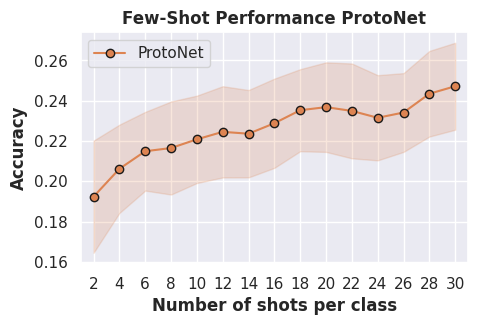

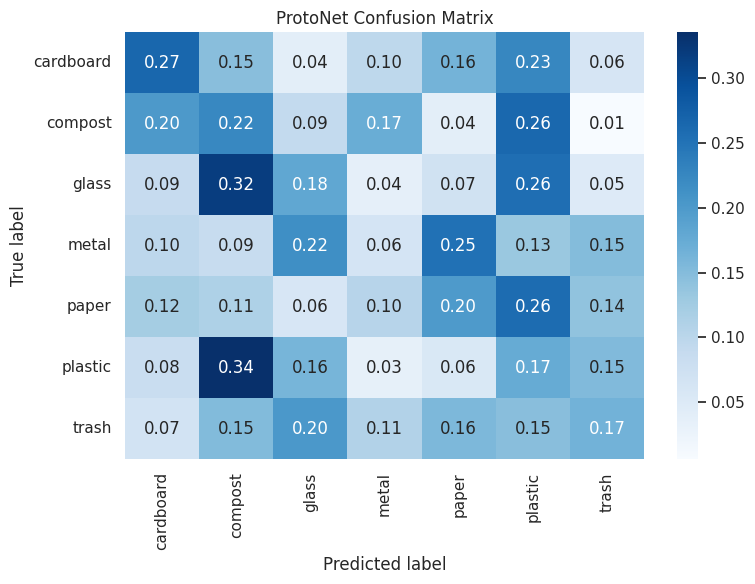

In [ ]:
#load model
# Recreate the model architecture
model = ProtoNet(proto_dim=64, lr=2e-4)

# Load saved weights, mapping to CPU
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/all models/LD_protonet_modelv3.3.ckpt"))

protonet_model_LD = model

import torch.optim as optim
import torch.nn.functional as F
import os
protonet_accuracies = dict()
data_feats = None
for k in range(2,31,2):# test at these different numers of support samples per class
    protonet_accuracies[k], data_feats = test_proto_net_fixed(protonet_model_LD, test_set, k_shot=k) ###INSTEAD OF USING test_proto_net just use the variable test_set and do a forward pass of the model to evaluate
    print(f"Accuracy for k={k}: {100.0*protonet_accuracies[k][0]:4.2f}% (+-{100*protonet_accuracies[k][1]:4.2f}%)")

#protonet_model feed test_set into it and then extract accuracy either per-class accuracy or single accuracy
#the confusion matrix and then a total model accuracy, evaluate the confusion matrix/accuracy on a total combined dataset
#accuracy per epoch? -> learning rate if time

ax = plot_few_shot(protonet_accuracies, name="ProtoNet", color="C1")
plt.show()
plt.close()

#get and store labels
true_labels, predicted_labels = get_predictions_proto_net(
    protonet_model_LD,
    test_set,
    K_SHOT
)

#call conf_matrix  function
plot_confusion_matrix(
    true_labels,
    predicted_labels,
    test_set.dataset.classes,
    title="ProtoNet Confusion Matrix"
)

Extracting image features:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluating 2-shot:   0%|          | 0/50 [00:00<?, ?it/s]

Accuracy for k=2: 32.65% (+-6.02%)


Extracting image features:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluating 4-shot:   0%|          | 0/50 [00:00<?, ?it/s]

...

Evaluating 28-shot:   0%|          | 0/50 [00:00<?, ?it/s]

Accuracy for k=28: 46.35% (+-1.27%)


Extracting image features:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluating 30-shot:   0%|          | 0/50 [00:00<?, ?it/s]

Accuracy for k=30: 46.84% (+-1.30%)


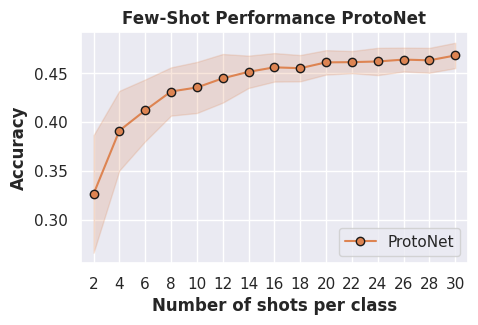

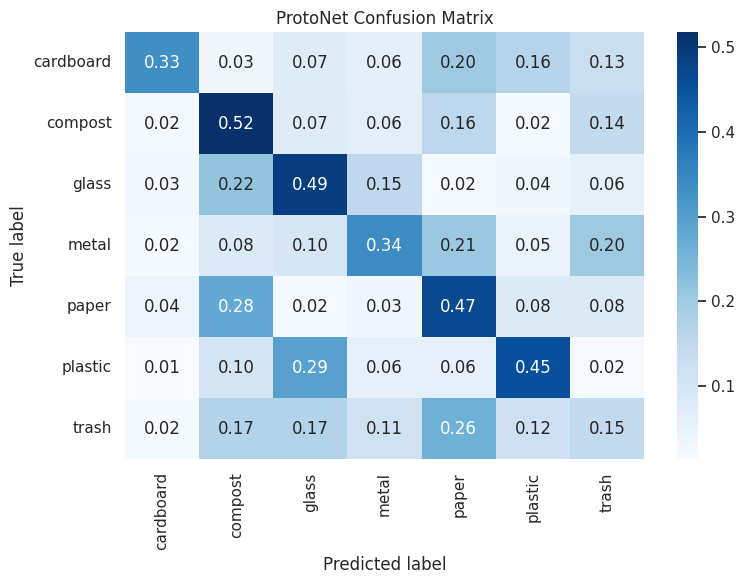

In [ ]:
#load model
# Recreate the model architecture
model = ProtoNet(proto_dim=64, lr=2e-4)

# Load saved weights
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/all models/LW_protonet_model_sepClasses.ckpt"))

protonet_model_LW = model

import torch.optim as optim
import torch.nn.functional as F
import os
protonet_accuracies = dict()
data_feats = None
for k in range(2,31,2):# test at these different numers of support samples per class
    protonet_accuracies[k], data_feats = test_proto_net_fixed(protonet_model_LW, test_set, k_shot=k) ###INSTEAD OF USING test_proto_net just use the variable test_set and do a forward pass of the model to evaluate
    print(f"Accuracy for k={k}: {100.0*protonet_accuracies[k][0]:4.2f}% (+-{100*protonet_accuracies[k][1]:4.2f}%)")

ax = plot_few_shot(protonet_accuracies, name="ProtoNet", color="C1")
plt.show()
plt.close()

#get and store labels
true_labels, predicted_labels = get_predictions_proto_net(
    protonet_model_LW,
    test_set,
    K_SHOT
)

#call conf_matrix  function
plot_confusion_matrix(
    true_labels,
    predicted_labels,
    test_set.dataset.classes,
    title="ProtoNet Confusion Matrix"
)

Extracting image features:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluating 2-shot:   0%|          | 0/50 [00:00<?, ?it/s]

Accuracy for k=2: 24.37% (+-4.02%)


Extracting image features:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluating 4-shot:   0%|          | 0/50 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c33071b5d00>
Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7c33071b5d00>    
self._shutdown_workers()Traceback (most recent call last):

Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
        self._shutdown_workers()<function _MultiProcessingDataLoaderIter.__del__ at 0x7c33071b5d00>if w.is_alive():


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
          i

Extracting image features:   0%|          | 0/12 [00:00<?, ?it/s]

^AssertionError^: ^can only test a child process^
^^^
AssertionError: can only test a child process


Evaluating 30-shot:   0%|          | 0/50 [00:00<?, ?it/s]

Accuracy for k=30: 34.83% (+-1.13%)


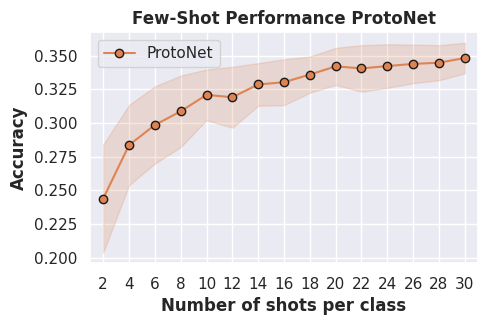

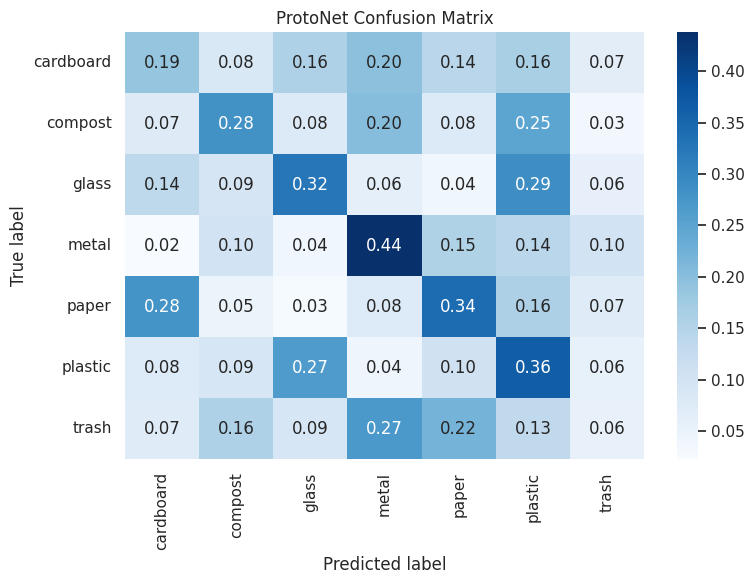

In [ ]:
#load model
# Recreate the model architecture
model = ProtoNet(proto_dim=64, lr=2e-4)

# Load saved weights
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/all models/protonet_modelv3.ckpt"))

protonet_model_DA = model

import torch.optim as optim
import torch.nn.functional as F
import os
protonet_accuracies = dict()
data_feats = None
for k in range(2,31,2):# test at these different numers of support samples per class
    protonet_accuracies[k], data_feats = test_proto_net_fixed(protonet_model_DA, test_set, k_shot=k) ###INSTEAD OF USING test_proto_net just use the variable test_set and do a forward pass of the model to evaluate
    print(f"Accuracy for k={k}: {100.0*protonet_accuracies[k][0]:4.2f}% (+-{100*protonet_accuracies[k][1]:4.2f}%)")

ax = plot_few_shot(protonet_accuracies, name="ProtoNet", color="C1")
plt.show()
plt.close()

#get and store labels
true_labels, predicted_labels = get_predictions_proto_net(
    protonet_model_DA,
    test_set,
    K_SHOT
)

#call conf_matrix  function
plot_confusion_matrix(
    true_labels,
    predicted_labels,
    test_set.dataset.classes,
    title="ProtoNet Confusion Matrix"
)

Extracting image features:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluating 2-shot:   0%|          | 0/50 [00:00<?, ?it/s]

Accuracy for k=2: 36.23% (+-3.74%)


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c33071b5d00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7c33071b5d00>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()^^
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    ^if w.is_alive():^^
 ^ ^ ^ ^ ^

Extracting image features:   0%|          | 0/12 [00:00<?, ?it/s]

...

Evaluating 28-shot:   0%|          | 0/50 [00:00<?, ?it/s]

Accuracy for k=28: 44.62% (+-1.40%)


Extracting image features:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluating 30-shot:   0%|          | 0/50 [00:00<?, ?it/s]

Accuracy for k=30: 44.84% (+-1.42%)


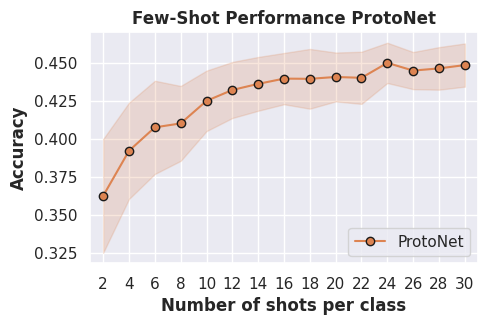

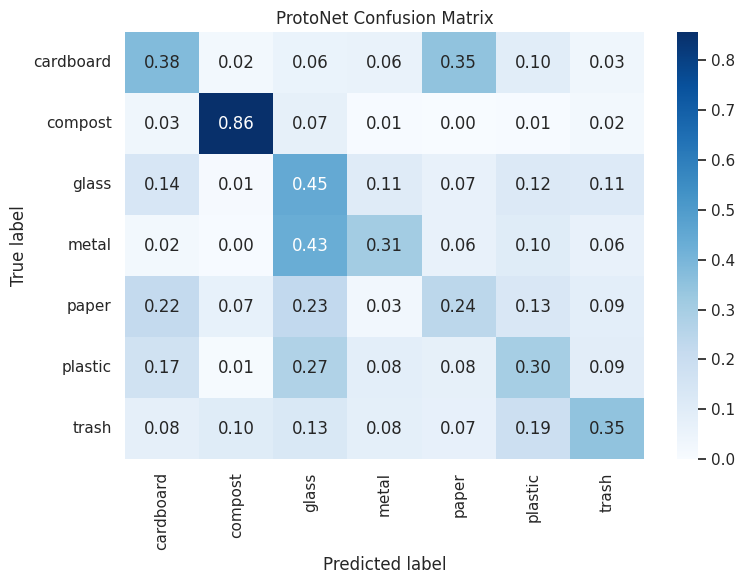

In [ ]:
#load model
# Recreate the model architecture
model = ProtoNet(proto_dim=64, lr=2e-4)

# Load saved weights
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/all models/addition/HL_NEW_protonet_modelv3.3.ckpt"))

protonet_model_hy2 = model

import torch.optim as optim
import torch.nn.functional as F
import os
protonet_accuracies = dict()
data_feats = None
for k in range(2,31,2):# test at these different numers of support samples per class
    protonet_accuracies[k], data_feats = test_proto_net_fixed(protonet_model_hy2, test_set, k_shot=k) ###INSTEAD OF USING test_proto_net just use the variable test_set and do a forward pass of the model to evaluate
    print(f"Accuracy for k={k}: {100.0*protonet_accuracies[k][0]:4.2f}% (+-{100*protonet_accuracies[k][1]:4.2f}%)")

ax = plot_few_shot(protonet_accuracies, name="ProtoNet", color="C1")
plt.show()
plt.close()

#get and store labels
true_labels, predicted_labels = get_predictions_proto_net(
    protonet_model_hy2,
    test_set,
    K_SHOT
)

#call conf_matrix  function
plot_confusion_matrix(
    true_labels,
    predicted_labels,
    test_set.dataset.classes,
    title="ProtoNet Confusion Matrix"
)

Extracting image features:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluating 2-shot:   0%|          | 0/50 [00:00<?, ?it/s]

Accuracy for k=2: 88.59% (+-2.97%)


Extracting image features:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluating 4-shot:   0%|          | 0/50 [00:00<?, ?it/s]

...

Accuracy for k=28: 94.30% (+-0.42%)


Extracting image features:   0%|          | 0/12 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c33071b5d00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c33071b5d00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Evaluating 30-shot:   0%|          | 0/50 [00:00<?, ?it/s]

Accuracy for k=30: 94.41% (+-0.49%)


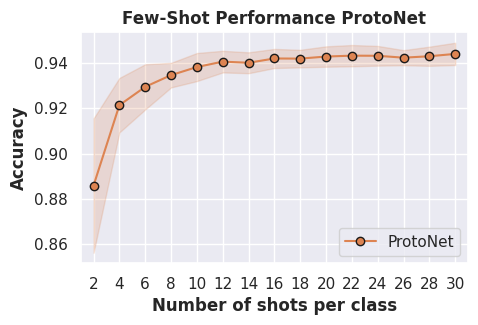

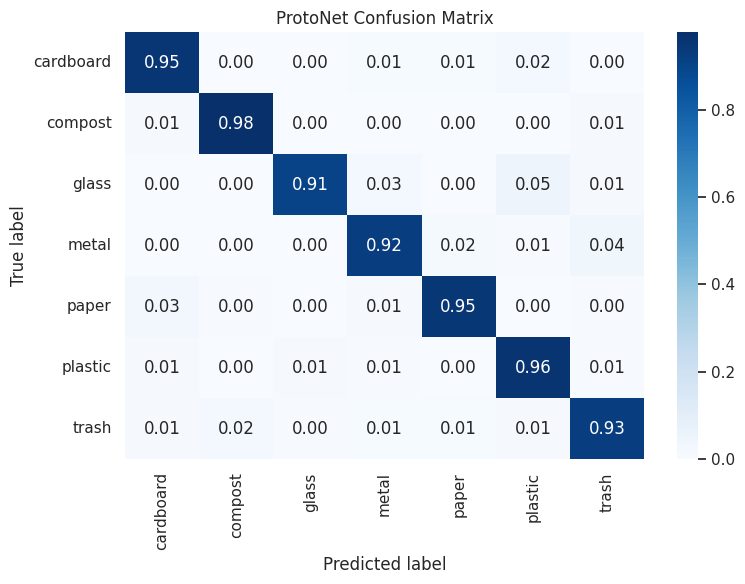

In [ ]:
#load model
# Recreate the model architecture
model = ProtoNet(proto_dim=64, lr=2e-4)

# Load saved weights
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/all models/addition/protonet_modelv3.3_CombinedDataset.ckpt"))

all2 = model

import torch.optim as optim
import torch.nn.functional as F
import os
protonet_accuracies = dict()
data_feats = None
for k in range(2,31,2):# test at these different numers of support samples per class
    protonet_accuracies[k], data_feats = test_proto_net_fixed(all2, test_set, k_shot=k) ###INSTEAD OF USING test_proto_net just use the variable test_set and do a forward pass of the model to evaluate
    print(f"Accuracy for k={k}: {100.0*protonet_accuracies[k][0]:4.2f}% (+-{100*protonet_accuracies[k][1]:4.2f}%)")

ax = plot_few_shot(protonet_accuracies, name="ProtoNet", color="C1")
plt.show()
plt.close()

#get and store labels
true_labels, predicted_labels = get_predictions_proto_net(
    all2,
    test_set,
    K_SHOT
)

#call conf_matrix  function
plot_confusion_matrix(
    true_labels,
    predicted_labels,
    test_set.dataset.classes,
    title="ProtoNet Confusion Matrix"
)

In [ ]:
import os
import torch
import pandas as pd

# Your checkpoint paths
model_paths = {
    "Combined": "/content/drive/MyDrive/Colab Notebooks/all models/addition/protonet_modelv3.3_CombinedDataset.ckpt",
    "Hy": "/content/drive/MyDrive/Colab Notebooks/all models/addition/HL_NEW_protonet_modelv3.3.ckpt",
    "Daniel": "/content/drive/MyDrive/Colab Notebooks/all models/protonet_modelv3.ckpt",
    "Wong": "/content/drive/MyDrive/Colab Notebooks/all models/LW_protonet_model_sepClasses.ckpt",
    "Docherty": "/content/drive/MyDrive/Colab Notebooks/all models/LD_protonet_modelv3.3.ckpt",
}

def summarize_checkpoint_sizes(model_class, model_kwargs, model_paths, map_location="cpu"):
    """
    model_class: class used to recreate model, e.g. ProtoNet
    model_kwargs: dict of model init args, e.g. {"proto_dim": 64, "lr": 2e-4}
    model_paths: dict of {model_name: checkpoint_path}
    """

    results = []

    for name, path in model_paths.items():
        row = {
            "Model": name,
            "Path Exists": os.path.exists(path),
            "Checkpoint Size (MB)": None,
            "Total Params": None,
            "Trainable Params": None,
            "Estimated In-Memory Size (MB)": None,
        }

        if not os.path.exists(path):
            results.append(row)
            continue

        # File size on disk
        row["Checkpoint Size (MB)"] = os.path.getsize(path) / (1024 ** 2)

        # Recreate model and load weights
        model = model_class(**model_kwargs)
        state_dict = torch.load(path, map_location=map_location)
        model.load_state_dict(state_dict)
        model.eval()

        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

        total_bytes = (
            sum(p.numel() * p.element_size() for p in model.parameters()) +
            sum(b.numel() * b.element_size() for b in model.buffers())
        )

        row["Total Params"] = total_params
        row["Trainable Params"] = trainable_params
        row["Estimated In-Memory Size (MB)"] = total_bytes / (1024 ** 2)

        results.append(row)

    df = pd.DataFrame(results)
    return df

In [ ]:
df_sizes = summarize_checkpoint_sizes(
    model_class=ProtoNet,
    model_kwargs={"proto_dim": 64, "lr": 2e-4},
    model_paths=model_paths,
    map_location="cpu"
)

print(df_sizes)

      Model  Path Exists  Checkpoint Size (MB)  Total Params  \
0  Combined         True              3.858345        962912   
1        Hy         True              3.853325        962912   
2    Daniel         True              3.852705        962912   
3      Wong         True              3.856485        962912   
4  Docherty         True              3.853325        962912   

   Trainable Params  Estimated In-Memory Size (MB)  
0            962912                       3.734535  
1            962912                       3.734535  
2            962912                       3.734535  
3            962912                       3.734535  
4            962912                       3.734535  


In [ ]:
df_sizes = df_sizes.sort_values("Checkpoint Size (MB)", ascending=False)
display(df_sizes)

,Model,Path Exists,Checkpoint Size (MB),Total Params,Trainable Params,Estimated In-Memory Size (MB)
0,Combined,True,3.858345,962912,962912,3.734535
3,Wong,True,3.856485,962912,962912,3.734535
1,Hy,True,3.853325,962912,962912,3.734535
4,Docherty,True,3.853325,962912,962912,3.734535
2,Daniel,True,3.852705,962912,962912,3.734535


In [2]:
!pip install thop

In [16]:
import torch
from thop import profile

def get_encoder_complexity(ckpt_path, proto_dim=64, lr=2e-4, input_size=(1,3,128,128)):
    checkpoint = torch.load(ckpt_path, map_location="cpu")

    model = ProtoNet(proto_dim=proto_dim, lr=lr)

    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        model.load_state_dict(checkpoint["state_dict"])
    else:
        model.load_state_dict(checkpoint)

    model.eval()
    encoder = model.model
    encoder.eval()

    dummy_input = torch.randn(*input_size)
    macs, params = profile(encoder, inputs=(dummy_input,), verbose=False)

    print(f"Parameters: {params:,}")
    print(f"MACs: {macs:,}")
    print(f"Approx FLOPs: {2 * macs:,}")

    return macs, params

In [19]:
get_encoder_complexity("/content/drive/MyDrive/Colab Notebooks/all models/MobileNet.ckpt")

Parameters: 1,583,456.0
MACs: 20,840,248.0
Approx FLOPs: 41,680,496.0


(20840248.0, 1583456.0)

In [23]:
get_encoder_complexity("/content/drive/MyDrive/Colab Notebooks/all models/DenseNet.ckpt")

Parameters: 962,912.0
MACs: 334,088,960.0
Approx FLOPs: 668,177,920.0


(334088960.0, 962912.0)